<a href="https://colab.research.google.com/github/rajulaanusree937-hub/task-4-sentiment-analysis/blob/main/task4_sentiment_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install textblob

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

In [4]:
file_path = "/content/train.ft.txt"

In [5]:
reviews = []

with open(file_path, "r", encoding="utf-8") as file:
    for i, line in enumerate(file):
        reviews.append(line.strip())
        if i == 9999:
            break

print(len(reviews))

10000


In [6]:
reviews = []

with open("train.ft.txt", "r", encoding="utf-8") as file:
    for i, line in enumerate(file):
        reviews.append(line.strip())

        if i == 9999:
            break

print("Total Reviews Loaded:", len(reviews))

Total Reviews Loaded: 10000


__label__1
__label__2

In [7]:
data = []

for review in reviews:
    parts = review.split(" ", 1)

    if len(parts) == 2:
        label = parts[0]
        text = parts[1]

        data.append([label, text])

df = pd.DataFrame(data, columns=["label", "review"])

df.head()

,label,review
0,__label__2,Stuning even for the non-gamer: This sound tra...
1,__label__2,The best soundtrack ever to anything.: I'm rea...
2,__label__2,Amazing!: This soundtrack is my favorite music...
3,__label__2,Excellent Soundtrack: I truly like this soundt...
4,__label__2,"Remember, Pull Your Jaw Off The Floor After He..."


In [8]:
print(df.shape)

df.info()

(10000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [9]:
df.isnull().sum()

,0
label,0
review,0


In [10]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

In [11]:
df["predicted_sentiment"] = df["review"].apply(get_sentiment)

df.head()

,label,review,predicted_sentiment
0,__label__2,Stuning even for the non-gamer: This sound tra...,Negative
1,__label__2,The best soundtrack ever to anything.: I'm rea...,Positive
2,__label__2,Amazing!: This soundtrack is my favorite music...,Positive
3,__label__2,Excellent Soundtrack: I truly like this soundt...,Positive
4,__label__2,"Remember, Pull Your Jaw Off The Floor After He...",Positive


In [12]:
sentiment_counts = df["predicted_sentiment"].value_counts()

print(sentiment_counts)

predicted_sentiment
Positive    7409
Negative    2430
Neutral      161
Name: count, dtype: int64


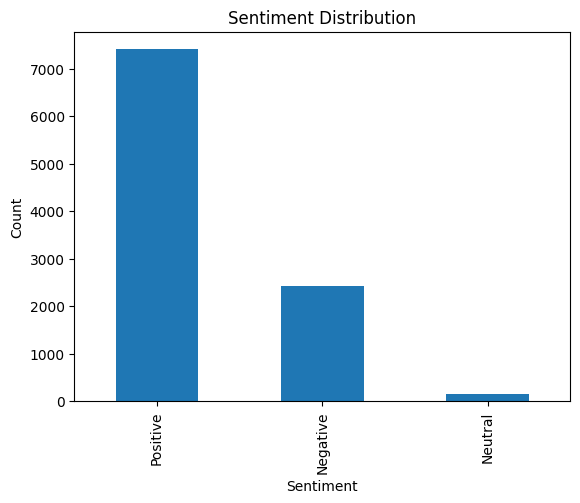

In [13]:
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

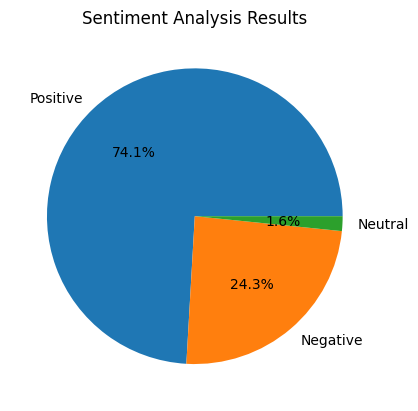

In [14]:
sentiment_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sentiment Analysis Results")

plt.ylabel("")

plt.show()

In [15]:
df[
    ["review", "predicted_sentiment"]
].head(10)

,review,predicted_sentiment
0,Stuning even for the non-gamer: This sound tra...,Negative
1,The best soundtrack ever to anything.: I'm rea...,Positive
2,Amazing!: This soundtrack is my favorite music...,Positive
3,Excellent Soundtrack: I truly like this soundt...,Positive
4,"Remember, Pull Your Jaw Off The Floor After He...",Positive
5,an absolute masterpiece: I am quite sure any o...,Positive
6,"Buyer beware: This is a self-published book, a...",Positive
7,Glorious story: I loved Whisper of the wicked ...,Positive
8,A FIVE STAR BOOK: I just finished reading Whis...,Positive
9,Whispers of the Wicked Saints: This was a easy...,Positive


In [16]:
print("KEY INSIGHTS")

print()

print("1. Reviews were classified into Positive, Negative, and Neutral categories.")

print("2. Sentiment analysis was performed using Natural Language Processing.")

print("3. Most reviews belong to either positive or negative sentiment groups.")

print("4. TextBlob successfully identified sentiment polarity from review text.")

print("5. Visualizations help understand sentiment distribution.")

KEY INSIGHTS

1. Reviews were classified into Positive, Negative, and Neutral categories.
2. Sentiment analysis was performed using Natural Language Processing.
3. Most reviews belong to either positive or negative sentiment groups.
4. TextBlob successfully identified sentiment polarity from review text.
5. Visualizations help understand sentiment distribution.


In [17]:
df.to_csv(
    "sentiment_analysis_results.csv",
    index=False
)

print("Results Saved Successfully")

Results Saved Successfully
